<img src="../img/RLSS26_banner.png" alt="rlss-logo"/>

Reinforcement Learning Summer School 2026 Edition, Milan, Italy.

<div align="center">

[Leonardo Cesani](mailto:leonardo.cesani@polimi.it) **•** [Enrique Mateos](mailto:enmateos@pa.uc3m.es) **•** [Gianmarco Tedeschi](mailto:gianmarco.tedeschi@polimi.it) **•** [Davide Tenedini](mailto:davide.tenedini@polimi.it)

</div>

---
# RL Basics II: Reinforcement Learning with Policy Gradient Methods
---

Welcome to the second tutorial on RL Basics @ RLSS 2026!

This notebook introduces a fundamental family of reinforcement learning algorithms: **Policy Gradient (PG) methods**. Many real-world problems involve continuous action spaces or complex environments where value-based methods struggle. PG methods offer an alternative by directly learning a parameterized policy, which makes them a natural fit for these problems.

Our goal is to build and train an agent with This notebook introduces a fundamental family of reinforcement learning algorithms: **PG methods**. Many real-world problems involve continuous action spaces or complex environments where value-based methods struggle. PG methods offer an alternative by directly learning a parameterized policy, which makes them a natural fit for these problems.
 and neural networks, step by step. We work entirely in a **continuous control** setting, and along the way we implement and *run* the full progression of estimators that modern deep RL is built on, comparing each one against the previous:

1. **PGs and the score function** — the objective, the policy gradient theorem, and how to represent a policy. We make the score function explicit on a linear-Gaussian policy, then move to a neural Gaussian policy.
2. **REINFORCE/GPOMDP and baselines** — the Monte-Carlo PG with reward-to-go (causal credit assignment), and variance reduction via a baseline. We implement it first by hand with the explicit score on the linear policy, then, with the usage of a surrogate loss, on the neural Gaussian policy.
3. **Actor-Critic methods** — replacing the fixed baseline with a learned state-value function, turning the reward-to-go into an advantage, and training an actor and a critic together.

Each section pairs the theory you need with hands-on coding. We keep the notation and the code interfaces consistent throughout, so that every section builds directly on the previous one and the four methods can be overlaid on the same plot on the inverted pendulum. Finally, we scale up to a harder task, and benchmark our actor-critic against state-of-the-art algorithms such as **PPO** from [Stable-Baselines3](https://stable-baselines3.readthedocs.io/en/master/?badge=master), on the same experience budget.

Notation used throughout: policy parameters are $\boldsymbol{\theta}$; a trajectory is $\tau = (s_0, a_0, r_0, s_1, \dots)$ of horizon $H$; the index $t$ runs over time steps within a trajectory; $N$ is the number of trajectories (rollouts) in a batch; $\gamma$ is the discount factor; and $\hat{R}_t$ denotes the discounted reward-to-go from time $t$.

# ⚙️ Setup

Run the cell below to install and import all the notebook requirements.
<br>Use the `is_animated` flag to turn on/off the rendering of the environment

_Remark._ If you're running the notebook on your machine, use `Python 3.11`. You can install all the requirements in your environment through the `requirements.txt` file.

In [1]:
import sys, os
if 'google.colab' in sys.modules:
    !pip install gymnasium
    !pip install numpy
    !pip install matplotlib
    !pip install torch
    !pip install seaborn
    !git clone https://github.com/gianmtedeschi/tutorial-rlss26.git


from utils import *

is_animated = True

---
# 🎮 Introduction to Policy Gradient RL
---

In this section we provide a brief explaination on PG methods, which learn a policy by optimizing a performance index or **objective**. In RL the general objective is to maximize the expected return collected by acting in the environment. Suppose the agent's policy is parameterized by $\boldsymbol{\theta}$, so that actions are drawn from $\pi_{\boldsymbol{\theta}}(a \mid s)$. We can represent such a policy with any differentiable function, like linear functions or neural networks with parameters $\boldsymbol{\theta}$. The goal of a PG algorithm is then to find the parameters that maximize

$$J(\boldsymbol{\theta}) = \mathbb{E}_{\tau \sim \pi_{\boldsymbol{\theta}}}\,[\,R(\tau)\,],$$

where $\tau$ is a trajectory and $R(\tau)$ its return, representing how good the policy is performing during the trajectory.

One way to maximize $J(\boldsymbol{\theta})$ is gradient ascent:

$$\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k + \alpha\, \nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})\big|_{\boldsymbol{\theta}_k},$$

where $\alpha$ is the step size or learning rate. The quantity $\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$ is the policy gradient. The [policy gradient theorem](https://proceedings.neurips.cc/paper_files/paper/1999/file/464d828b85b0bed98e80ade0a5c43b0f-Paper.pdf) states that it can be written as an expectation over trajectories sampled from the current policy:

$$\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \mathbb{E}_{\tau \sim \pi_{\boldsymbol{\theta}}}\Big[\sum_{t=0}^{H-1} \nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a_t \mid s_t)\, R(\tau)\Big].$$

Informally, the policy gradient is the gradient of the log-probability of each chosen action, weighted by the return of the trajectory it belonged to. The REINFORCE algorithm, which we build in the next section, is the simplest algorithm exploiting this identity: it increases the probability of actions that tend to lead to high-return trajectories.

The term $\nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a \mid s)$ is called the score function. It is the central object of this first section: we compute it by hand for a simple policy before letting autograd take over in the sections that follow.

## The Environment

In the following exercises, we use [InvertedPendulum-v5](https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/), the MuJoCo continuous-control environment, which can be seen as the continous version of CartPole. A cart moves along a track and must keep a pole balanced upright. The crucial difference from CartPole is the action space:

- The **state** is a 4-dimensional continuous vector (cart position and velocity, pole angle and angular velocity).
- The **action** is a single continuous force applied to the cart, in the range $[-3, 3]$, rather than a discrete left/right choice.
- The agent receives a reward of $+1$ for every timestep the pole stays upright, and the episode ends when the pole falls. The return of an episode is therefore the number of steps the agent kept the pole balanced.

Because the action is continuous, we represent the policy with a **Gaussian** distribution over actions, rather than the categorical (softmax) distribution used for discrete environments. This choice is consistent across all three sections.

 🔁 **Recap from Part 1**: an *environment* is the task we want to solve; the agent interacts with it via an *action*, collects a *reward* that drives learning, and observes the next *state*. An *episode* (also called a *trajectory* or *rollout*) is the sequence of states, actions and rewards the agent experiences over time.

In [2]:
env_id = "InvertedPendulum-v5"

# Training and evaluation run on a plain env (no rendering) -- this is what keeps
# the notebook fast. A separate rendering env is used only to record animations.
env = gym.make(env_id)
render_env = gym.make(env_id, render_mode="rgb_array")

# State and action space sizes
s_size = env.observation_space.shape[0]
a_size = env.action_space.shape[0]

In [3]:
print("Observation space\n")
print("The state space is:", s_size)
print("Sample observation:", env.observation_space.sample())

Observation space

The state space is: 4
Sample observation: [ 0.34514094 -0.91340641 -0.03503837  2.89435269]


In [4]:
print("Action space\n")
print("The action space is:", a_size)
print("Action bounds:", env.action_space.low, "to", env.action_space.high)
print("Action space sample:", env.action_space.sample())

Action space

The action space is: 1
Action bounds: [-3.] to [3.]
Action space sample: [-2.1914482]


## Policies

In RL a policy defines the behaviour of an agent by mapping states to actions. Formally a policy $\pi$ takes a state and returns an action. We distinguish:

- A **deterministic policy** always returns the same action for a given state, $a = \pi(s)$.
- A **stochastic policy** returns a distribution over actions, $\pi(a \mid s) = \mathbb{P}(a \mid s)$, from which the agent samples.

PG methods need a differentiable, stochastic policy, so that the score $\nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a \mid s)$ is well-defined. The policy network takes the current state as input and outputs the parameters of an action distribution; its weights are learned to maximize cumulative reward.

For continuous actions we use a **Gaussian policy**,

$$\pi_{\boldsymbol{\theta}}(a \mid s) = \mathcal{N}\big(\mu_{\boldsymbol{\theta}}(s),\, \sigma^2\big),$$

where $\mu_{\boldsymbol{\theta}}(s)$ is the mean action predicted by the policy and $\sigma$ controls how much the agent explores around that mean. The log-probability of an action under this policy is

$$\log \pi_{\boldsymbol{\theta}}(a \mid s) = -\frac{\lVert a - \mu_{\boldsymbol{\theta}}(s) \rVert^2}{2\sigma^2} - \log \sigma - \tfrac{1}{2}\log(2\pi),$$

and, when the mean is a linear function $\mu_{\boldsymbol{\theta}}(s) = W s$, the score with respect to $W$ has the closed form

$$\nabla_{W} \log \pi_{\boldsymbol{\theta}}(a \mid s) = \frac{\big(a - W s\big)\, s^\top}{\sigma^2}.$$

We will use exactly this closed form in this section, then let autograd compute the equivalent gradient for a neural mean in the following sections.

### Two parameterizations

We meet two ways of parameterizing the Gaussian mean:

1. **Linear policies** are simple, interpretable and fast. They are useful for understanding PG methods, and on a balancing task like the inverted pendulum a linear feedback policy is already a reasonable controller.
2. **Neural-network policies** are more expressive, can model nonlinear behaviour, and are the standard in deep RL.

In this section, we implement a linear-Gaussian policy and compute its score by hand. From the next section onward we use a neural Gaussian policy and let PyTorch autograd compute gradients for us. This staging is deliberate: first understand the score, then automate it. Both share the same `BasePolicy` interface, so the shared training utilities work with either.

---

### A Brief Reminder on PyTorch

PyTorch is the deep-learning framework we use throughout. The concepts we rely on are:

- [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html), multi-dimensional arrays similar to NumPy arrays that can run on GPUs.
- [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html), the base class used to define neural networks and parameterized models.
- Automatic differentiation: PyTorch computes gradients via `autograd`.

```python
x = torch.tensor([2.0], requires_grad=True)
y = x ** 2
y.backward()
print(x.grad)  # dy/dx = 2x = 4
```

In PG methods, gradients are what tell us how to nudge $\boldsymbol{\theta}$ to increase the expected return.

---

Below is the common base class that all our policies inherit from. It fixes the interface (`draw_action`, `get_parameters`, `set_parameters`, and so on) used by the shared training utilities. It must not be modified.

In [5]:
class BasePolicy(nn.Module):
    """Common interface shared by every policy in this notebook."""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        raise NotImplementedError

    def distribution(self, obs):
        raise NotImplementedError

    def draw_action(self, obs, deterministic=False):
        raise NotImplementedError

    def get_parameters(self):
        raise NotImplementedError

    def set_parameters(self, theta):
        raise NotImplementedError

    def log_prob(self, obs, action):
        raise NotImplementedError

    def grad_log(self, obs, action):
        raise NotImplementedError

We also define a small helper that builds a multi-layer perceptron from a tuple of hidden-layer sizes. It is reused by the neural Gaussian policy and by the actor-critic network, so that the depth and width of every network in the notebook are controlled the same way, from the constructor.

In [6]:
def build_mlp(input_size, output_size, hidden_sizes=(64,), activation=nn.Tanh, is_critic=False):
    """
    Build a simple MLP. Reused by the neural policy and the actor-critic network.
    The depth and width are set entirely by `hidden_sizes`, e.g. (64,) or (64, 64).
    """
    layers = []
    in_features = input_size
    for h in hidden_sizes:
        layers.append(nn.Linear(in_features, h))
        layers.append(activation())
        in_features = h

    layers.append(nn.Linear(in_features, output_size))
    if not is_critic:
        layers.append(nn.Tanh())

    return nn.Sequential(*layers)

⭐ **Exercise.** We start with a shallow policy whose mean is a linear transformation of the state, $\mu_{\boldsymbol{\theta}}(s) = W s$, where $ W\in \mathbb R^{|\mathcal A|\times |\mathcal S|}$ and with a fixed exploration standard deviation $\sigma$. This policy has a single weight matrix $W$, so the score function has the closed form given above and we can compute it by hand.

Fill in the three gaps:

1. In `__init__`, construct the initial `W` matrix, keeping in mind it's dimensions! (see [`torch.randn`](https://pytorch.org/docs/stable/generated/torch.randn.html)).
2. In `forward`, compute the mean by multiplying the weight matrix by the observation (use the matrix-multiplication operator `@`).
3. In `draw_action`, compute the mean action (via `foward`). If the policy is **not** deterministic, sample an action by adding Gaussian noise of scale $\sigma$ to the mean (see [`torch.randn_like`](https://pytorch.org/docs/stable/generated/torch.randn_like.html)).
4. In `log_prob`, compute the closed-form log probabilities $\log \pi_{\boldsymbol{\theta}}(a \mid s)$.
5. In `grad_log`, implement the closed-form score $\big(a - Ws\big)s^\top / \sigma^2$ (see [`torch.outer`](https://pytorch.org/docs/stable/generated/torch.outer.html)), returned as a flat vector of length `self.dim`.

*Hint.* The formulas for points 3 and 4 are already defined above, in the Policy cell.

In [ ]:
class ShallowGaussianPolicy(BasePolicy):
    """Linear-Gaussian policy with a manually computed score (teaching device)."""
    def __init__(self, s_size, a_size, std=0.5):
        super().__init__()
        self.s_size = s_size
        self.a_size = a_size
        self.dim = a_size * s_size               # number of parameters in W
        # --- WRITE YOUR SOLUTION HERE --- #
        self.W = torch.randn(a_size, s_size, requires_grad=False) * 0.1
        # --- END SOLUTION --- #
        self.std = torch.tensor(std, requires_grad=False)

    def forward(self, x):
        # --- WRITE YOUR SOLUTION HERE --- #
        mean = ...                       
        # --- END SOLUTION --- #
        return mean

    def draw_action(self, obs, deterministic=False):
        # --- WRITE YOUR SOLUTION HERE --- #
        action = ...
        if not deterministic:
            epsilon = ...
            action = ...
        # --- END SOLUTION --- #
        return action.detach().numpy()

    def get_parameters(self):
        return self.W.detach().numpy().ravel()

    def set_parameters(self, theta):
        self.W = torch.from_numpy(theta.reshape(self.a_size, self.s_size)).float()

    def log_prob(self, obs, action):
        mu = self.forward(torch.from_numpy(obs).float())
        # --- WRITE YOUR SOLUTION HERE --- #
        diff = ...
        log_prob = ...
        return log_prob
        # --- END SOLUTION --- #

    def grad_log(self, obs, action):
        """Score nabla_theta log pi(a|s), returned as a flat vector of length self.dim."""
        obs_t = torch.from_numpy(obs).float()
        action_t = torch.as_tensor(action).float()
        mu = self.forward(obs_t)
        # --- WRITE YOUR SOLUTION HERE --- #
        diff = ...                              
        score = ...
        # --- END SOLUTION --- #
        return score.ravel()

⭐ **Exercise.** The neural policy replaces the linear mean with an MLP, $\mu_{\boldsymbol{\theta}}(s) = \text{MLP}_{\boldsymbol{\theta}}(s)$, and makes the log standard deviation a learnable parameter so the agent can adjust its own exploration. We no longer compute the score by hand: from here on, autograd differentiates `log_prob` for us.

Fill in the two gaps:

1. In `distribution`, build a [`Normal`](https://pytorch.org/docs/stable/distributions.html#normal) distribution with the network's mean and the standard deviation `self.log_std.exp()`.
2. In `draw_action`, sample an action from that distribution (or return the mean when `deterministic=True`).

In [ ]:
class GaussianPolicy(BasePolicy):
    """Neural Gaussian policy: an MLP predicts the mean, with a learnable log-std.
    Gradients are obtained via autograd, so no manual score is needed.
    """
    def __init__(self, s_size, a_size, exploration_std=0.1, hidden_sizes=(64,), activation=nn.Tanh):
        super().__init__()
        self.s_size = s_size
        self.a_size = a_size
        self.network = build_mlp(s_size, a_size, hidden_sizes, activation)

        if exploration_std <= 0:
            raise ValueError(f"exploration_std must be positive, got {exploration_std}")
        self.log_std = nn.Parameter(
            torch.log(torch.full((a_size,), float(exploration_std)))
        )

    def forward(self, x):
        return self.network(x)

    def distribution(self, obs):
        # --- WRITE YOUR SOLUTION HERE --- #
        mean = ...
        dist = ...
        # --- END SOLUTION --- #
        return dist

    def draw_action(self, obs, deterministic=False):
        obs_t = torch.from_numpy(obs).float()
        with torch.no_grad(): # Avoids tracking gradients
            # --- WRITE YOUR SOLUTION HERE --- #
            if deterministic:
                return ...
            return ...
            # --- END SOLUTION --- #

    def log_prob(self, obs, action):
        """Sum the per-dimension log-probabilities of `action` under the policy."""
        dist = self.distribution(obs)
        return dist.log_prob(action).sum(-1)

    def get_parameters(self):
        return nn.utils.parameters_to_vector(self.parameters()).detach()

    def set_parameters(self, theta):
        nn.utils.vector_to_parameters(
            torch.as_tensor(theta, dtype=torch.float32), self.parameters()
        )

Before training anything, we check that both policies behave as expected: the linear-Gaussian score should be a flat vector of length `s_size * a_size`, and the neural policy should return an action of the right shape.

In [9]:
# Sanity checks
obs = env.reset()[0]

gauss_linear = ShallowGaussianPolicy(s_size, a_size)
log_probs = gauss_linear.log_prob(obs, np.zeros(a_size))
print("Linear-Gaussian log-prob shape:", log_probs.shape, "(expected torch.Size([]))")
score = gauss_linear.grad_log(obs, np.zeros(a_size))
print("Linear-Gaussian score shape:", tuple(score.shape), "(expected", (s_size * a_size,), ")")

gauss_nn = GaussianPolicy(s_size, a_size, hidden_sizes=(64,))
action = gauss_nn.draw_action(obs)
print("Neural policy sampled action:", action, "(expected shape", (a_size,), ")")

Linear-Gaussian log-prob shape: torch.Size([]) (expected torch.Size([]))
Linear-Gaussian score shape: (4,) (expected (4,) )
Neural policy sampled action: [-0.23660173] (expected shape (1,) )


---
# 📈 PG Methods: REINFORCE, GPOMDP and Baselines
---

PG methods directly optimize a parameterized stochastic policy $\pi_{\boldsymbol{\theta}}(a \mid s)$ to maximize the expected return. Unlike value-based methods, which derive a policy implicitly from value estimates, they estimate the gradient of the expected return and perform gradient ascent directly on $\boldsymbol{\theta}$. Recall the objective and its gradient from the previous section:

$$J(\boldsymbol{\theta}) = \mathbb{E}_{\tau \sim \pi_{\boldsymbol{\theta}}}[R(\tau)],
\qquad
\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \mathbb{E}_{\tau \sim \pi_{\boldsymbol{\theta}}}\Big[\sum_{t=0}^{H-1} \nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a_t \mid s_t)\, R(\tau)\Big].$$

This lets us estimate the gradient from sampled trajectories. The generic procedure is iterative: collect data, estimate the gradient, update the parameters, and repeat.

**Algorithm 1 — Policy Gradient (PG)**
***
**Input:** MDP $\mathcal{M}$, number of iterations $T$, learning-rate schedule $(\eta^{(t)})_{t=0}^{T-1}$<br>
**Output:** approximately optimal parameters $\boldsymbol{\theta}^{(T)}$

1. Initialize $\boldsymbol{\theta}^{(0)}$ arbitrarily.
2. **for** $t = 0, 1, \dots, T-1$ **do**
    - Estimate the policy gradient $\widehat{\nabla}_{\boldsymbol{\theta}} J(\boldsymbol{\theta}^{(t)})$.
    - Update $\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} + \eta^{(t)}\, \widehat{\nabla}_{\boldsymbol{\theta}} J(\boldsymbol{\theta}^{(t)})$.
3. **end for**
4. **return** $\boldsymbol{\theta}^{(T)}$
***

In Algorithm 1, the index $t$ denotes the outer training iteration. In the derivations below, $t$ denotes the time step within a trajectory and $H$ the horizon.

## REINFORCE and the Reward-to-go (GPOMDP)

[REINFORCE](https://link.springer.com/content/pdf/10.1007/BF00992696.pdf) is the foundational Monte-Carlo policy gradient method: it estimates the gradient from complete sampled episodes. While unbiased, it suffers from prohibitively high variance. 

This variance fundamentally stems from how REINFORCE aggregates information. The standard estimator multiplies the sum of the scores over the entire trajectory by the full trajectory return:

$$
\nabla_{\boldsymbol{\theta}}^{\text{REINFORCE}} J(\boldsymbol{\theta}) \approx \frac{1}{N} \sum_{i=1}^{N} \left( \sum_{t=0}^{H-1} \nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a_{i,t} \mid s_{i,t}) \right) \left( \sum_{t=0}^{H-1} \gamma^t r(s_{i,t}, a_{i,t}) \right).
$$

While correct in expectation, this naive formulation violates temporal causality. Expanding the product reveals cross-terms where an action $a_t$ is weighted by a reward $r_l$ collected *before* time $t$ ($l < t$). Because an action cannot possibly have influenced past rewards, these specific terms have an expected value of zero but inject substantial noise into the empirical estimate.

The remedy is to explicitly enforce causality. By dropping the terms where rewards precede actions, we ensure that the score of an action at time $t$ is only multiplied by the "reward-to-go"—the discounted sum of rewards collected from $t$ onward. This truncated estimator significantly reduces variance without introducing bias, and is formally known as the [GPOMDP](https://arxiv.org/pdf/1106.0665) estimator:

$$
\nabla_{\boldsymbol{\theta}}^{\text{GPOMDP}} J(\boldsymbol{\theta}) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{H-1} \nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a_{i,t} \mid s_{i,t}) \sum_{l=t}^{H-1} \gamma^l r(s_{i,l}, a_{i,l}).
$$

By simply swapping the order of the sums, we obtain an algebraically equivalent form of GPOMDP. Instead of summing over time and computing the forward-looking reward-to-go, we can sum over the rewards and multiply each by the accumulation of "rolling scores" up to that point:

$$
\nabla_{\boldsymbol{\theta}}^{\text{GPOMDP}} J(\boldsymbol{\theta}) = \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{H-1} \gamma^t r(s_{i,t}, a_{i,t}) \sum_{l=0}^{t} \nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a_{i,l} \mid s_{i,l}).
$$

We implement this estimator twice: first with the explicit hand-computed score on the linear policy, then with autograd on the neural policy. The two are mathematically identical; the difference lies solely in how the score function is evaluated.

A note on terminology. Historically, "REINFORCE" strictly refers to the naive full-trajectory formulation, while the causality-respecting estimator is GPOMDP. However, in modern literature, the reward-to-go variant is so universally adopted that it has largely co-opted the name REINFORCE. To keep our comparisons readable, we use a single naming convention throughout and distinguish the variants by their structural additions: **REINFORCE (linear)** and **REINFORCE (neural)** for the parameterizations, **REINFORCE + baseline** once we add variance reduction, and **Actor-Critic** for the learned-baseline version. All of these implementations fundamentally rely on the GPOMDP estimator derived above.

⭐ **Exercise.** Implement the GPOMDP estimator for the linear policy using the manually computed score `policy.grad_log`. You are given a list of collected trajectories `rollouts`. Each trajectory is composed of H tuples `(s, a, r)`. Compute the `(H, dim)` tensor of per-step scores and an `(H, 1)` tensor of discounted rewards. Then compute the gradient.

*Hint.* Use [`torch.cumsum`](https://pytorch.org/docs/stable/generated/torch.cumsum.html) along the time axis to accumulate the scores $\sum_{l=0}^{t} \nabla_{\boldsymbol{\theta}} \log \pi$, multiply by the discounted rewards, and sum over the horizon.

In [ ]:
def gpomdp_linear(rollouts: list[tuple[np.ndarray, np.ndarray, float]], policy, gamma):
    """GPOMDP estimator using an explicit, hand-computed score (linear-Gaussian policy).
    Returns a flat gradient vector, to be used with manual gradient ascent.
    """
    grad = 0
    for roll in rollouts:
        H = len(roll)
        disc_rew = torch.zeros((H, 1))
        scores = torch.zeros((H, policy.dim))

        # Retrieve the per-step score and discounted reward
        # --- WRITE YOUR SOLUTION HERE --- #
        for t in range(H):
            s, a, r = ...
            disc_rew[t] = ...
            scores[t] = ...

        cum_scores = ...
        grad += ...
        # --- END SOLUTION --- #

    return grad / len(rollouts)

We train the linear policy with a simple loop that performs manual gradient ascent: get the parameters, add the (learning-rate-scaled) gradient, and set them back. This is the most literal possible implementation of Algorithm 1, and it makes clear what the optimizer will later do for us automatically.

In [11]:
def train_linear(env, policy, gamma, m, K, alpha, T):
    """Train a linear policy by gradient ascent with the reward-to-go estimator.

    :param m: rollouts collected per iteration.
    :param K: number of training iterations.
    :param alpha: the gradient-ascent step size.
    :param T: maximum trajectory length.
    :return: a list of (mean_return, standard_error), one entry per iteration.
    """
    results = [evaluate(env, policy, T, gamma)]

    for k in range(K):
        print('Iteration:', k)
        rollouts = collect_rollouts(env, policy, m, T)

        theta = policy.get_parameters()
        pg = gpomdp_linear(rollouts, policy, gamma).numpy()
        policy.set_parameters(theta + alpha * pg)

        results.append(evaluate(env, policy, T, gamma))

    return results

⭐ **Exercise.** Run the linear policy on the inverted pendulum. A linear feedback controller is already a sensible policy for a balancing task, so you should see the return climb steadily, although it tends to be noisy because the gradient estimate is high-variance and the learning rate is constant.

We store the resulting curve in `all_results` so that the later sections can compare against it.

In [14]:
discount_factor = 0.99   # @param
batch_size = 50           # @param  (rollouts per iteration, N)
iterations = 100           # @param
learning_rate = 0.001      # @param
trajectory_length = 200   # @param  (native episode cap is 1000)
exploration_std = 0.1     # @param
seed = 0                  # @param

seed_everything(seed)

# Instantiate and train the linear policy
linear_policy = ShallowGaussianPolicy(s_size, a_size, std=exploration_std)
linear_results = train_linear(env, linear_policy, discount_factor, batch_size,
                              iterations, learning_rate, trajectory_length)

all_results['REINFORCE (linear)'] = linear_results

Mean reward: 19.6 Std reward: 1.86 Num episodes: 10
Iteration: 0
Mean reward: 21.0 Std reward: 1.98 Num episodes: 10
Iteration: 1
Mean reward: 22.0 Std reward: 2.17 Num episodes: 10
Iteration: 2
Mean reward: 19.0 Std reward: 1.65 Num episodes: 10
Iteration: 3
Mean reward: 22.2 Std reward: 2.38 Num episodes: 10
Iteration: 4
Mean reward: 21.2 Std reward: 1.95 Num episodes: 10
Iteration: 5
Mean reward: 23.5 Std reward: 2.7 Num episodes: 10
Iteration: 6
Mean reward: 29.4 Std reward: 2.95 Num episodes: 10
Iteration: 7
Mean reward: 22.7 Std reward: 2.33 Num episodes: 10
Iteration: 8
Mean reward: 25.9 Std reward: 2.68 Num episodes: 10
Iteration: 9
Mean reward: 24.5 Std reward: 1.94 Num episodes: 10
Iteration: 10
Mean reward: 33.9 Std reward: 3.53 Num episodes: 10
Iteration: 11
Mean reward: 34.6 Std reward: 3.87 Num episodes: 10
Iteration: 12
Mean reward: 34.3 Std reward: 3.36 Num episodes: 10
Iteration: 13
Mean reward: 29.9 Std reward: 2.35 Num episodes: 10
Iteration: 14
Mean reward: 35.4 Std

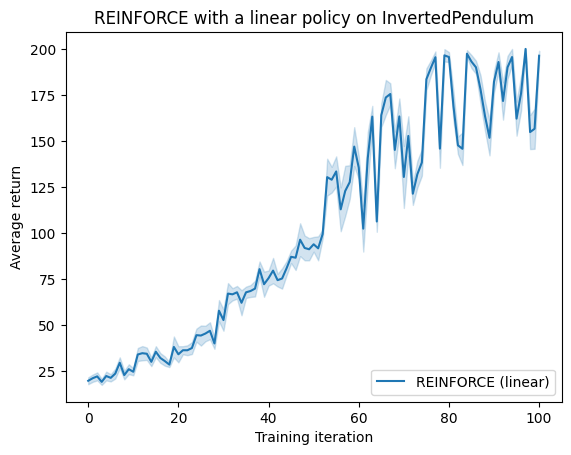

In [15]:
plt.figure()
plot_results(linear_results, label='REINFORCE (linear)')
plt.title('REINFORCE with a linear policy on InvertedPendulum')
plt.show()

In [16]:
# Watch the trained linear policy balance the pole
if is_animated:
    frames = record_episode(render_env, linear_policy)
    animate(frames)

## REINFORCE for Any Network, via a Surrogate Loss

Computing the score by hand only works for simple policies. For a neural policy we instead build a scalar **surrogate loss** whose gradient with respect to $\boldsymbol{\theta}$ is exactly the GPOMDP estimator, and let autograd do the rest:

$$\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{H-1} \hat{R}_{i,t} \, \log \pi_{\boldsymbol{\theta}}(a_{i,t} \mid s_{i,t}).$$

Differentiating $\mathcal{L}$ reproduces the reward-to-go estimator, because the reward-to-go is treated as a constant weight on each log-probability. Since we maximize $J$, the training loop will minimize $-\mathcal{L}$. The function below therefore returns the scalar loss $\mathcal{L}$, and the optimizer handles the sign.

⭐ **Exercise.** Fill in the computation of the discounted reward-to-go.

*Hint.* Compute it in reverse order to properly accumulate the discount factor. You can use builtin function `reversed()`

In [ ]:
def reinforce(rollouts, policy, gamma, baseline=None):
    """
    Surrogate-loss REINFORCE (reward-to-go / GPOMDP) for any autograd policy.
    Returns the scalar loss L; the training loop minimizes -L (i.e. ascends J).
    """
    # Pre-compute the discounted rewards-to-go for every rollout
    all_rewards_to_go = []
    for roll in rollouts:
        H = len(roll)
        
        # --- WRITE YOUR SOLUTION HERE --- #
        rewards_to_go = ...

        # --- END SOLUTION --- #
        all_rewards_to_go.append(rewards_to_go)

    # As a default, use 0.0 as a baseline, so the weights are just the rewards-to-go. If a baseline is provided, it is subtracted from the rewards-to-go to reduce variance, which we will see in the next section.
    weights = torch.cat(all_rewards_to_go)
    b = 0.0 if baseline is None else baseline(weights) 

    # Stack every transition and score them in one pass
    states = torch.tensor(
        np.array([s for roll in rollouts for (s, _, _) in roll]), dtype=torch.float32
    )
    actions = torch.tensor(
        np.array([a for roll in rollouts for (_, a, _) in roll]), dtype=torch.float32
    )

    log_probs = policy.log_prob(states, actions)
    total_loss = torch.sum((weights - b) * log_probs)
    return total_loss / len(rollouts)

Because the estimator returns a scalar loss, we can use a standard PyTorch optimizer: we maximize $J$ by minimizing $-\mathcal{L}$. This is the same training pattern we reuse, almost verbatim, for the actor-critic algorithm we will see later.

In [18]:
def train(env, policy, gamma, m, K, alpha, T, baseline=None):
    """Train a policy with the autograd reward-to-go REINFORCE estimator.

    :param baseline: if provided, subtract the baseline from the rewards-to-go.
    :return: a list of (mean_return, standard_error), one entry per iteration.
    """
    optimizer = optim.Adam(policy.parameters(), lr=alpha)
    results = [evaluate(env, policy, T, gamma)]

    for k in range(K):
        print('Iteration:', k)
        rollouts = collect_rollouts(env, policy, m, T)

        loss = reinforce(rollouts, policy, gamma, baseline=baseline)
        optimizer.zero_grad()
        (-loss).backward()           # maximize the objective by minimizing its negative
        optimizer.step()

        results.append(evaluate(env, policy, T, gamma))

    return results

⭐ **Exercise.** Train the neural Gaussian policy with `baseline=None`. Then plot its curve together with the linear policy's curve obtained running the `gpomdp_linear` function. Because the network is more expressive, it should reach a similar or higher return; the comparison also lets you see how the two estimators behave under the same budget.

In [19]:
discount_factor = 0.99       # @param
batch_size = 50           # @param  (rollouts per iteration, N)
iterations = 100           # @param
learning_rate = 0.005     # @param
trajectory_length = 200   # @param  (native episode cap is 1000)
n_hidden = (32, 32)       # @param
exploration_std = 0.5     # @param
seed = 0                  # @param

seed_everything(seed)

# Instantiate and train the neural policy (no baseline yet)
nn_policy = GaussianPolicy(s_size, a_size, exploration_std, hidden_sizes=n_hidden)
reinforce_results = train(env, nn_policy, discount_factor, batch_size,
                          iterations, learning_rate, trajectory_length)

all_results['REINFORCE (neural)'] = reinforce_results

Mean reward: 7.5 Std reward: 0.52 Num episodes: 10
Iteration: 0
Mean reward: 12.2 Std reward: 1.45 Num episodes: 10
Iteration: 1
Mean reward: 17.4 Std reward: 3.6 Num episodes: 10
Iteration: 2
Mean reward: 16.8 Std reward: 3.12 Num episodes: 10
Iteration: 3
Mean reward: 12.3 Std reward: 1.45 Num episodes: 10
Iteration: 4
Mean reward: 20.0 Std reward: 3.05 Num episodes: 10
Iteration: 5
Mean reward: 26.0 Std reward: 4.14 Num episodes: 10
Iteration: 6
Mean reward: 28.0 Std reward: 4.04 Num episodes: 10
Iteration: 7
Mean reward: 36.0 Std reward: 7.03 Num episodes: 10
Iteration: 8
Mean reward: 34.2 Std reward: 3.71 Num episodes: 10
Iteration: 9
Mean reward: 43.7 Std reward: 6.88 Num episodes: 10
Iteration: 10
Mean reward: 64.4 Std reward: 6.65 Num episodes: 10
Iteration: 11
Mean reward: 62.5 Std reward: 16.91 Num episodes: 10
Iteration: 12
Mean reward: 66.1 Std reward: 5.43 Num episodes: 10
Iteration: 13
Mean reward: 72.0 Std reward: 6.44 Num episodes: 10
Iteration: 14
Mean reward: 75.4 Std

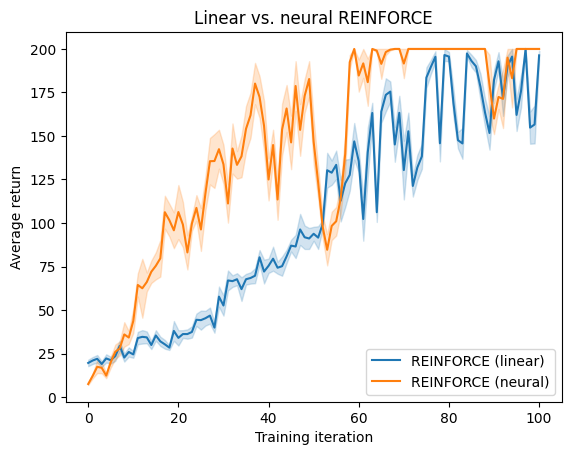

In [20]:
# Comparison between the performance obtained with linear and neural policies
compare_results(
    {'REINFORCE (linear)': all_results['REINFORCE (linear)'],
     'REINFORCE (neural)': all_results['REINFORCE (neural)']},
    title='Linear vs. neural REINFORCE'
)

In [21]:
# Watch the trained neural policy
if is_animated:
    frames = record_episode(render_env, nn_policy)
    animate(frames)

## Baselines

A well-known way to reduce the variance further is to subtract a baseline $b$ from the reward-to-go:

$$\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{H-1} \nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a_{i,t} \mid s_{i,t}) \big(\hat{R}_{i,t} - b\big).$$

This stays unbiased as long as $b$ does not depend on the action $a_{i,t}$, which follows from the log-derivative trick:

$$\mathbb{E}_{\pi_{\boldsymbol{\theta}}}\big[\nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(a_t \mid s_t)\, b\big] = b\, \nabla_{\boldsymbol{\theta}} \underbrace{\sum_a \pi_{\boldsymbol{\theta}}(a \mid s_t)}_{=\,1} = 0.$$

So subtracting $b$ leaves the expectation of the estimator unchanged while reducing its variance. Two common choices are:

- A **constant baseline** $b = c$, a fixed scalar such as the average return over a long window. It is simple but does not adapt to the current policy.
- An **average baseline**, the mean reward-to-go over the current batch,
$$b = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{H} \sum_{t=0}^{H-1} \hat{R}_{i,t},$$
which adapts automatically at each iteration and requires no extra hyperparameters. This is the most common simple choice, and it is the we will implement.

In the next section we go one step further and let the baseline depend on the state, $b = V(s_t)$, learned by a neural network. That is the actor-critic approach.

⭐ **Exercise.** The `reinforce` function already supports the average baseline through its `baseline` function: compute $b$ as the mean of all rewards-to-go across the batch and pass the function. `reinforce` will subtract it from each $\hat{R}_{i,t}$.

Before running, predict the effect: subtracting a constant baseline does not change the expected gradient, so the mean curve should be similar, but the variance of the updates should drop, which often shows up as a smoother curve or a tighter shaded band. Train with the new baseline, and overlay all the curves.

In [ ]:
def compute_baseline(weights):
    """Compute the average reward-to-go baseline."""
    # --- WRITE YOUR SOLUTION HERE --- #
    b = ...
    return b
    # --- END SOLUTION --- #

In [24]:
discount_factor = 0.99       # @param
batch_size = 50           # @param  (rollouts per iteration, N)
iterations = 100           # @param
learning_rate = 0.005      # @param
trajectory_length = 200   # @param  (native episode cap is 1000)
n_hidden = (32, 32)       # @param
exploration_std = 0.5     # @param
seed = 0                  # @param

seed_everything(seed)

# Same policy and budget as Exercise 2.4, now with the average baseline
nn_policy_bl = GaussianPolicy(s_size, a_size, exploration_std, hidden_sizes=n_hidden)
baseline_results = train(env, nn_policy_bl, discount_factor, batch_size,
                         iterations, learning_rate, trajectory_length,
                         baseline=compute_baseline)

all_results['REINFORCE + baseline'] = baseline_results

Mean reward: 7.5 Std reward: 0.52 Num episodes: 10
Iteration: 0
Mean reward: 10.6 Std reward: 1.3 Num episodes: 10
Iteration: 1
Mean reward: 18.2 Std reward: 2.88 Num episodes: 10
Iteration: 2
Mean reward: 15.1 Std reward: 1.95 Num episodes: 10
Iteration: 3
Mean reward: 20.1 Std reward: 4.03 Num episodes: 10
Iteration: 4
Mean reward: 30.2 Std reward: 6.65 Num episodes: 10
Iteration: 5
Mean reward: 19.8 Std reward: 3.69 Num episodes: 10
Iteration: 6
Mean reward: 33.9 Std reward: 4.96 Num episodes: 10
Iteration: 7
Mean reward: 31.6 Std reward: 4.03 Num episodes: 10
Iteration: 8
Mean reward: 36.3 Std reward: 5.83 Num episodes: 10
Iteration: 9
Mean reward: 38.5 Std reward: 7.33 Num episodes: 10
Iteration: 10
Mean reward: 38.2 Std reward: 5.21 Num episodes: 10
Iteration: 11
Mean reward: 58.5 Std reward: 7.37 Num episodes: 10
Iteration: 12
Mean reward: 61.4 Std reward: 8.0 Num episodes: 10
Iteration: 13
Mean reward: 85.0 Std reward: 14.81 Num episodes: 10
Iteration: 14
Mean reward: 98.9 Std 

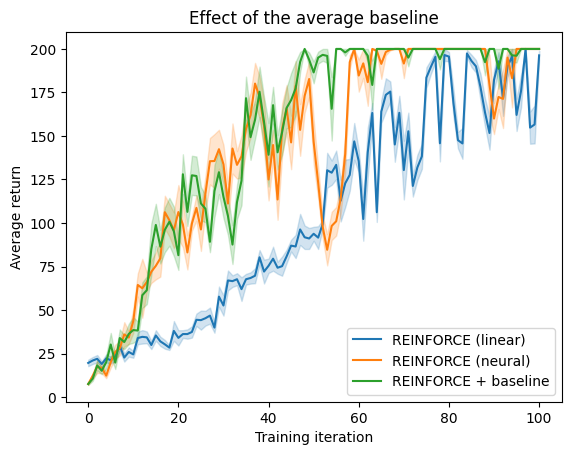

In [25]:
compare_results(
    {'REINFORCE (linear)': all_results['REINFORCE (linear)'],
     'REINFORCE (neural)': all_results['REINFORCE (neural)'],
     'REINFORCE + baseline': all_results['REINFORCE + baseline']},
    title='Effect of the average baseline'
)

In [26]:
# Watch the policy trained with the baseline
if is_animated:
    frames = record_episode(render_env, nn_policy_bl)
    animate(frames)

---
# 🎭 Actor-Critic Methods
---

So far the baseline has been either absent (REINFORCE) or a single scalar averaged over the batch (Section 2.3). Both ignore an obvious fact: some states are simply worth more than others. A principled, state-dependent baseline is the state-value function $V(s)$, the expected return from state $s$ under the current policy. Subtracting it from the reward-to-go gives the advantage, which measures how much better an action was than the policy's average behaviour in that state:

$$A_t = \hat{R}_t - V(s_t),$$

where $\hat{R}_t$ is the same reward-to-go used in GPOMDP. Because $V(s_t)$ does not depend on the action, the estimator stays unbiased by the same argument as in Section 2.3, but a good $V$ reduces variance far more than a constant baseline can.

In actor-critic methods we learn $V(s)$ alongside the policy. The model has two parts:

1. The **critic** estimates $V(s)$ and is trained to minimize the squared error against the observed return.
2. The **actor** is the policy $\pi_{\boldsymbol{\theta}}$, trained to increase the probability of advantageous actions.

The two losses we minimize are

$$\mathcal{L}_{\text{actor}} = -\frac{1}{H} \sum_{t=0}^{H-1} \log \pi_{\boldsymbol{\theta}}(a_t \mid s_t)\, A_t,
\qquad
\mathcal{L}_{\text{critic}} = \frac{1}{H} \sum_{t=0}^{H-1} \big(\hat{R}_t - V(s_t)\big)^2.$$

The actor loss is exactly the surrogate loss from Section 2, with the learned advantage $A_t$ in place of the reward-to-go. This is the natural endpoint of the variance-reduction story: no baseline, then a constant baseline, then a learned state-dependent baseline.

⭐ **Exercise.** We build a single module with two MLPs, an actor and a critic, both created with `build_mlp` and both controlled by the same `hidden_sizes` argument, so that depth and width are set from the constructor exactly as for the policy in Section 1 (for example `hidden_sizes=(64,)` for one hidden layer, or `(64, 64)` for two). The actor predicts the Gaussian mean, with a learnable log standard deviation; the critic predicts a single state value.

Fill in the `forward` method:

1. Pass `obs` through `self.actor` to get the mean and build a `Normal` distribution with `self.log_std.exp()`.
2. Pass `obs` through `self.critic` and `squeeze(-1)` the result so that the value is one-dimensional.

In [ ]:
class GaussianActorCritic(BasePolicy):
    """Gaussian actor and a value critic, as two separate MLPs.
    Depth and width are set from the constructor via `hidden_sizes`, the same way
    as the policy network in Section 1.
    """
    def __init__(self, s_size, a_size, exploration_std, hidden_sizes=(64,), activation=nn.Tanh):
        super().__init__()
        self.actor = build_mlp(s_size, a_size, hidden_sizes, activation, is_critic=False)
        self.critic = build_mlp(s_size, 1, hidden_sizes, activation, is_critic=True)
        if exploration_std <= 0:
            raise ValueError(f"exploration_std must be positive, got {exploration_std}")
        self.log_std = nn.Parameter(
            torch.log(torch.full((a_size,), float(exploration_std)))
        )
        
    def draw_action(self, obs, deterministic=False):
        """Sample an action; compatible with collect_rollouts and evaluate."""
        obs_t = torch.from_numpy(obs).float()
        with torch.no_grad():
            action = self.actor(obs_t)
            if not deterministic:
                action = Normal(action, self.log_std.exp()).sample()
            return action.detach().numpy()

    def forward(self, obs):
        """Return (action distribution, state value)."""
        # --- WRITE YOUR SOLUTION HERE --- #
        mean = ...
        dist = ...
        value = ...
        # --- END SOLUTION --- #
        return dist, value

⭐ **Exercise.** We reuse `collect_rollouts` from the shared utilities. We pool the transitions from every rollout in the batch into flat tensors, compute the discounted rewards-to-go, and then query the network for $V(s)$ and the log-probabilities of the actions taken. The actor and the critic have separate optimizers, which lets us give the critic a larger learning rate and update it several times per iteration.

The order matters: we update the critic first, for a few epochs on the collected batch, so that by the time we update the actor the value function is already a useful baseline. With only a single critic update per iteration the value estimate stays poor for a long time, the advantage is noisy, and the agent learns slowly and erratically; the extra critic passes are what make the actor-critic both stronger and more reliable than plain REINFORCE.

Fill in the training blocks for the critic and the actor, with the following measures:

1. The advantage $A_t = \hat{R}_t - V(s_t)$. Use `.detach()` on the values so the actor update does not back-propagate through the critic.
2. The actor loss $-\tfrac{1}{H}\sum_t \log \pi_{\boldsymbol{\theta}}(a_t \mid s_t)\, A_t$.
3. The critic loss $\tfrac{1}{H}\sum_t (\hat{R}_t - V(s_t))^2$.

*Hint.* When updating the network parameters, follow this order:
1. Compute the loss.
2. Zero out the gradient (see `zero_grad()`).
3. Compute the gradient (via `backward`).
4. Update the parameters via the optimizer.

In [ ]:
def train_actor_critic(env, policy, gamma, m, K, alpha_pi, alpha_v, T, critic_epochs=5, eval_episodes=10, eval_gamma=None):
    """Train an actor-critic policy, with separate optimizers for the actor and critic.

    The critic is updated `critic_epochs` times per iteration. Updating it more than
    once lets the value estimate catch up to the current policy, so the advantage it
    provides is a more useful learning signal for the actor.

    :return: a list of (mean_return, standard_error), one entry per iteration.
    """
    if eval_gamma is None:
        eval_gamma = gamma
    
    pi_optimizer = optim.Adam(policy.actor.parameters(), lr=alpha_pi)
    v_optimizer = optim.Adam(policy.critic.parameters(), lr=alpha_v)

    results = [evaluate(env, policy, T, eval_gamma, eval_episodes)]

    for k in range(K):
        print('Iteration:', k)
        rollouts = collect_rollouts(env, policy, m, T)

        # Gather all transitions in the batch into flat tensors.
        states_list, actions_list, returns_list = [], [], []
        for roll in rollouts:
            H = len(roll)
            states = torch.tensor(np.array([step[0] for step in roll]), dtype=torch.float32)
            actions = torch.tensor(np.array([step[1] for step in roll]), dtype=torch.float32)
            
            returns = torch.zeros(H)
            G = 0.0
            for t in reversed(range(H)):
                G = roll[t][2] + gamma * G
                returns[t] = G

            states_list.append(states)
            actions_list.append(actions)
            returns_list.append(returns)

        states = torch.cat(states_list)
        actions = torch.cat(actions_list)
        returns = torch.cat(returns_list)

        # Train the critic to predict the returns
        for _ in range(critic_epochs):
            # --- WRITE YOUR SOLUTION HERE --- #
            _, values = ...
            critic_loss = ...

            # --- END SOLUTION --- #

        # Train the actor, using the critic's value as the baseline
        # --- WRITE YOUR SOLUTION HERE --- #
        dist, values = ...
        actor_loss = ...

        # --- END SOLUTION --- #

        results.append(evaluate(env, policy, T, eval_gamma, eval_episodes))

    return results

⭐ **Exercise.** Train the actor-critic agent on the inverted pendulum, then overlay its curve on the REINFORCE curves from Section 2. Because the baseline is now a learned state-value function, the actor-critic update typically has lower variance and reaches a higher return under the same budget.

Things to try: get the return clearly above the REINFORCE curves; compare the shaded variance bands; and, optionally, set `alpha_v = 0` so the critic never learns, which turns the advantage into a fixed (random) baseline and should noticeably hurt performance.

In [63]:
discount_factor = 0.99     # @param
batch_size = 50           # @param  (rollouts per iteration, N)
iterations = 100           # @param
actor_lr = 0.005           # @param
critic_lr = 0.01          # @param
trajectory_length = 200   # @param  (native episode cap is 1000)
n_hidden = (32, 32)       # @param
exploration_std = 0.5     # @param
critic_epochs = 30        # @param
seed = 0                  # @param

seed_everything(seed)

# Instantiate and train the actor-critic agent
ac_policy = GaussianActorCritic(s_size, a_size, exploration_std, hidden_sizes=n_hidden)
ac_results = train_actor_critic(env, ac_policy, discount_factor, batch_size,
                                iterations, actor_lr, critic_lr, trajectory_length,
                                critic_epochs=critic_epochs)

all_results['Actor-Critic'] = ac_results

Mean reward: 9.7 Std reward: 2.1 Num episodes: 10
Iteration: 0
Mean reward: 11.5 Std reward: 1.84 Num episodes: 10
Iteration: 1
Mean reward: 21.0 Std reward: 6.59 Num episodes: 10
Iteration: 2
Mean reward: 11.5 Std reward: 1.65 Num episodes: 10
Iteration: 3
Mean reward: 21.5 Std reward: 4.05 Num episodes: 10
Iteration: 4
Mean reward: 30.0 Std reward: 5.39 Num episodes: 10
Iteration: 5
Mean reward: 28.0 Std reward: 5.58 Num episodes: 10
Iteration: 6
Mean reward: 33.8 Std reward: 5.32 Num episodes: 10
Iteration: 7
Mean reward: 43.3 Std reward: 7.14 Num episodes: 10
Iteration: 8
Mean reward: 40.6 Std reward: 7.69 Num episodes: 10
Iteration: 9
Mean reward: 32.4 Std reward: 3.01 Num episodes: 10
Iteration: 10
Mean reward: 63.3 Std reward: 8.54 Num episodes: 10
Iteration: 11
Mean reward: 58.3 Std reward: 11.09 Num episodes: 10
Iteration: 12
Mean reward: 62.3 Std reward: 11.54 Num episodes: 10
Iteration: 13
Mean reward: 70.7 Std reward: 13.55 Num episodes: 10
Iteration: 14
Mean reward: 69.4 S

### Putting It All Together

We have run four methods on the inverted pendulum with the same evaluation protocol, storing each training curve in `all_results`. The plot below overlays them, with the average return on each training iteration.

The methods are comparable iteration by iteration because they all collect the same number of rollouts per iteration, so each point on the x-axis corresponds to the same amount of collected experience. (The more advanced methods make slightly better use of that experience, but the data budget per iteration is the same.)

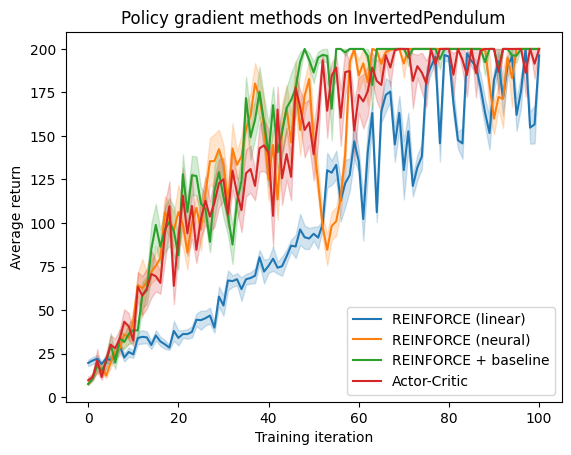

In [64]:
# Overlay every experiment we ran
compare_results(all_results, title='Policy gradient methods on InvertedPendulum')

In [31]:
# Watch the trained actor-critic agent
if is_animated:
    frames = record_episode(render_env, ac_policy)
    animate(frames)

Reading the curves from earlier to later in the notebook:

- The **linear policy** already learns to balance, because a linear feedback law is a reasonable controller for this task, though its curve is among the noisiest.
- The **neural policy** is more expressive and learns at least as well, usually a little more smoothly.
- **Adding the average baseline** leaves the expected gradient unchanged but reduces the variance of the updates, which tends to show up as a steadier curve.
- The **actor-critic** replaces the fixed baseline with a learned, state-dependent value function, and gives the strongest and most stable result of the four.

The exact ordering varies between runs because of the randomness in sampling. Each training cell calls `seed_everything` before building its policy, so re-running a cell reproduces its curve; change the `seed` parameter to see how stable each method is.

---
# 🛠️ A State-Of-The-Art algorithm on a Harder Task
---

On the inverted pendulum every method we built eventually works, because the task is easy. Real problems are harder, and the differences between algorithms become much clearer. To see this, we move to [HalfCheetah](https://gymnasium.farama.org/environments/mujoco/half_cheetah/), a classic continuous-control benchmark where the agent controls a two-legged robot and is rewarded for running forward as fast as possible. The state has 17 dimensions and the action has 6, and every episode runs for a fixed number of steps.

We will do two things: run our own actor-critic on this task, and compare it against a tested implementation of **Proximal Policy Optimization** (PPO) from the [Stable-Baselines3](https://stable-baselines3.readthedocs.io/) library.

PPO is an actor-critic method, with a policy and a value function and advantages computed just as we did. Its main addition is a safeguard on how much the policy is allowed to change at each update: instead of taking an unrestricted gradient step, it optimizes a *clipped* objective that keeps the new policy close to the old one. This makes learning far more stable and lets the algorithm reuse each batch of data for several updates. It is the same family of ideas we have built, with the engineering needed to make it robust.

## Our Actor-Critic on HalfCheetah

We reuse our `GaussianActorCritic` and `train_actor_critic` without changing them, only pointing them at the new environment. The reward here can be negative (the robot is penalised for moving backwards or for large efforts), so returns start below zero. Since every HalfCheetah episode has the same fixed length, we report the total episode reward (the undiscounted return), which is the standard score for this benchmark.

In [ ]:
hard_env_id = "HalfCheetah-v5"

# --- WRITE YOUR SOLUTION HERE --- #
hard_env = ...
hard_render_env = ...
# --- END SOLUTION --- #

hard_s_size = hard_env.observation_space.shape[0]
hard_a_size = hard_env.action_space.shape[0]
print("HalfCheetah: state", hard_s_size, "action", hard_a_size,
      "episode length", hard_env.spec.max_episode_steps)

HalfCheetah: state 17 action 6 episode length 1000


In [ ]:
hard_results = {}

discount_factor = 0.99        # @param
batch_size = 25            # @param  (rollouts per iteration, N)
iterations = 100           # @param
actor_lr = 0.001           # @param
critic_lr = 0.001          # @param
trajectory_length = 200   # @param
n_hidden = (64, 32)        # @param
exploration_std = 0.1      # @param
critic_epochs = 100        # @param
seed = 0                   # @param


seed_everything(seed)

hard_ac_policy = GaussianActorCritic(hard_s_size, hard_a_size, exploration_std, hidden_sizes=n_hidden)
hard_ac_results = train_actor_critic(hard_env, hard_ac_policy, discount_factor, batch_size,
                                     iterations, actor_lr, critic_lr, trajectory_length,
                                     critic_epochs=critic_epochs, eval_episodes=3, eval_gamma=1.0)

hard_results['Actor-Critic'] = hard_ac_results

Mean reward: -13.25 Std reward: 1.43 Num episodes: 3
Iteration: 0
Mean reward: -1.99 Std reward: 1.67 Num episodes: 3
Iteration: 1
Mean reward: 4.06 Std reward: 0.73 Num episodes: 3
Iteration: 2
Mean reward: 8.11 Std reward: 2.49 Num episodes: 3
Iteration: 3
Mean reward: 15.81 Std reward: 1.85 Num episodes: 3
Iteration: 4
Mean reward: 24.61 Std reward: 3.48 Num episodes: 3
Iteration: 5
Mean reward: 44.68 Std reward: 5.13 Num episodes: 3
Iteration: 6
Mean reward: 57.49 Std reward: 1.07 Num episodes: 3
Iteration: 7
Mean reward: 76.86 Std reward: 1.26 Num episodes: 3
Iteration: 8
Mean reward: 83.0 Std reward: 2.79 Num episodes: 3
Iteration: 9
Mean reward: 96.43 Std reward: 4.53 Num episodes: 3
Iteration: 10
Mean reward: 103.51 Std reward: 1.84 Num episodes: 3
Iteration: 11
Mean reward: 111.94 Std reward: 3.64 Num episodes: 3
Iteration: 12
Mean reward: 121.43 Std reward: 5.77 Num episodes: 3
Iteration: 13
Mean reward: 127.17 Std reward: 4.66 Num episodes: 3
Iteration: 14
Mean reward: 123.1

## PPO with Stable-Baselines3

**Proximal Policy Optimization** (PPO) builds directly upon the Actor-Critic architecture, but solves a fundamental failure mode: catastrophic policy collapse caused by taking a gradient step that is too large, which pushes the policy into a region of the parameter space where it can no longer generate useful trajectories to learn from.

To prevent this, PPO explicitly restricts how much the policy can change in a single update. It computes the probability ratio between the updated policy and the old policy:

$$r_t(\boldsymbol{\theta}) = \frac{\pi_{\boldsymbol{\theta}}(a_t \mid s_t)}{\pi_{\boldsymbol{\theta}_{\text{old}}}(a_t \mid s_t)}$$

Instead of the standard policy gradient objective, PPO maximizes a **clipped surrogate objective**. If an action has a positive advantage, the objective encourages increasing its probability, but clips the ratio at $1 + \epsilon$ to prevent the update from being too greedy. If the advantage is negative, it clips the penalty at $1 - \epsilon$:

$$L^{\text{CLIP}}(\boldsymbol{\theta}) = \mathbb{E} \left[ \min\left( r_t(\boldsymbol{\theta}) \hat{A}_t, \text{clip}(r_t(\boldsymbol{\theta}), 1 - \epsilon, 1 + \epsilon) \hat{A}_t \right) \right]$$

This objective allows PPO to safely perform multiple epochs of gradient ascent on the same batch of collected data, making it highly sample-efficient.

**Algorithm 2 — Proximal Policy Optimization (PPO)**
***
**Input:** MDP $\mathcal{M}$, iterations $K$, trajectories per iteration $N$, epochs $E$, clip range $\epsilon$, learning rate $\eta$<br>
**Output:** approximately optimal parameters $\boldsymbol{\theta}^{(K)}$

1. Initialize policy parameters $\boldsymbol{\theta}^{(0)}$ and critic parameters $\phi^{(0)}$ arbitrarily.
2. **for** $k = 0, 1, \dots, K-1$ **do**
    - Collect $N$ trajectories $\mathcal{D}_k = \{\tau_i\}_{i=1}^N$ by running policy $\pi_{\boldsymbol{\theta}^{(k)}}$ in $\mathcal{M}$.
    - Compute returns $\hat{R}_t$ and advantage estimates $\hat{A}_t$ based on the current critic $V_{\phi^{(k)}}$.
    - **for** $e = 1, \dots, E$ **do**
        - Compute probability ratio $r_t(\boldsymbol{\theta}) = \frac{\pi_{\boldsymbol{\theta}}(a_t \mid s_t)}{\pi_{\boldsymbol{\theta}^{(k)}}(a_t \mid s_t)}$.
        - Maximize surrogate objective $L^{\text{CLIP}}(\boldsymbol{\theta}) = \mathbb{E}_{\mathcal{D}_k} \left[ \min\left( r_t(\boldsymbol{\theta}) \hat{A}_t, \text{clip}(r_t(\boldsymbol{\theta}), 1 - \epsilon, 1 + \epsilon) \hat{A}_t \right) \right]$ via gradient ascent with rate $\eta$ to update $\boldsymbol{\theta}$.
        - Minimize value loss $L^{\text{VF}}(\phi) = \mathbb{E}_{\mathcal{D}_k} \left[ (V_\phi(s_t) - \hat{R}_t)^2 \right]$ via gradient descent with rate $\eta$ to update $\phi$.
    - **end for**
    - Set $\boldsymbol{\theta}^{(k+1)} \leftarrow \boldsymbol{\theta}$ and $\phi^{(k+1)} \leftarrow \phi$.
3. **end for**
4. **return** $\boldsymbol{\theta}^{(K)}$
***

### Using Stable-Baselines3

Implementing the clipped objective, advantage estimation (typically Generalized Advantage Estimation, GAE), and multiple-epoch batching from scratch requires significant engineering. [Stable-Baselines3](https://stable-baselines3.readthedocs.io/en/master/) (SB3) is a library of reliable, high-performance implementations that abstracts this complexity away.

In the upcoming exercise, your task is to instantiate and train a PPO agent using SB3, ensuring its learning curve can be fairly compared against our custom actor-critic. Here are the key hints to implement it correctly:

1. **Initialization:** You can instantiate the agent simply by passing the policy type (e.g., `"MlpPolicy"`), the Gymnasium environment instance, and a random seed to the `PPO` class.
2. **Interface Wrapping:** Because SB3 models have their own internal API (for example, their `predict` method returns a tuple of action and recurrent state), we provide an `SB3Policy` wrapper class. Wrap your instantiated model in this class so it exposes the exact same `draw_action` interface our custom evaluation functions expect.
3. **Chunked Training:** To plot the learning curve on the same iteration axis as our custom algorithms, do not train for the total interaction budget all at once. Instead, loop over the defined number of `iterations`. Inside the loop, call the model's `learn()` method for `steps_per_iteration` timesteps.
4. **Maintaining Schedules:** Crucially, when calling `learn()` inside the loop, you must pass `reset_num_timesteps=False`. This tells SB3 that it is continuing an ongoing training session, preserving internal learning rate schedules and logging steps rather than restarting them from zero each time.
5. **Evaluation:** Evaluate the wrapped policy before the loop begins, and then again after every single training chunk, appending the returns to your results list so they align perfectly with the custom algorithms.

Setting up and training PPO takes only a few lines. To make the comparison fair, we give PPO the same exact environmental interaction budget our custom actor-critic used: `batch_size * trajectory_length * iterations` total steps. We also evaluate it at regular checkpoints so its learning curve can be plotted on the same iteration axis as our implementations.


In [65]:
from stable_baselines3 import PPO


class SB3Policy:
    """Wrap a Stable-Baselines3 model so it exposes the same draw_action interface
    as our own policies, which lets us reuse evaluate() and record_episode()."""
    def __init__(self, model):
        self.model = model

    def draw_action(self, obs, deterministic=True):
        action, _ = self.model.predict(obs, deterministic=deterministic)
        return action

In [ ]:
# Same interaction budget as our actor-critic above
steps_per_iteration = batch_size * trajectory_length
total_steps = steps_per_iteration * iterations

seed_everything(seed)

# --- WRITE YOUR SOLUTION HERE --- #
model = ...
ppo_policy = ...

# Train in `iterations` chunks, evaluating after each so the curve aligns with ours
ppo_results = [evaluate(hard_env, ppo_policy, 1000, 1.0, num_episodes=3)]

for k in range(iterations):
    print('Iteration:', k)
    
# --- END SOLUTION --- #
            
hard_results['PPO (Stable-Baselines3)'] = ppo_results

Mean reward: -0.38 Std reward: 0.29 Num episodes: 3
Iteration: 0
Mean reward: -0.49 Std reward: 0.27 Num episodes: 3
Iteration: 1
Mean reward: -1.28 Std reward: 0.35 Num episodes: 3
Iteration: 2
Mean reward: 11.03 Std reward: 0.4 Num episodes: 3
Iteration: 3
Mean reward: 106.23 Std reward: 0.96 Num episodes: 3
Iteration: 4
Mean reward: -98.07 Std reward: 1.97 Num episodes: 3
Iteration: 5
Mean reward: -27.94 Std reward: 7.21 Num episodes: 3
Iteration: 6
Mean reward: -21.32 Std reward: 14.29 Num episodes: 3
Iteration: 7
Mean reward: -8.69 Std reward: 3.99 Num episodes: 3
Iteration: 8
Mean reward: -46.2 Std reward: 27.4 Num episodes: 3
Iteration: 9
Mean reward: 21.41 Std reward: 10.19 Num episodes: 3
Iteration: 10
Mean reward: 66.52 Std reward: 7.06 Num episodes: 3
Iteration: 11
Mean reward: 24.98 Std reward: 4.5 Num episodes: 3
Iteration: 12
Mean reward: 39.84 Std reward: 14.3 Num episodes: 3
Iteration: 13
Mean reward: 79.88 Std reward: 39.42 Num episodes: 3
Iteration: 14
Mean reward: 14

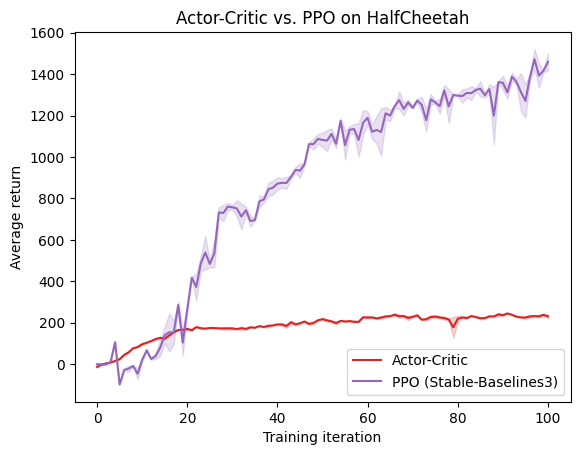

In [58]:
# Compare our actor-critic against PPO on HalfCheetah, iteration by iteration
compare_results(hard_results, title='Actor-Critic vs. PPO on HalfCheetah')

In [ ]:
# Watch the trained PPO agent run
if is_animated:
    frames = record_episode(hard_render_env, ppo_policy)
    animate(frames)